## Big Picture
"Which videos outperform expectation, why, and under what statistical structure?”


--- Custom Regression Summary ---
R-squared: 0.5887
Intercept (β0): 2.7783
Log_Subs Coef (β1): 0.6148
Log_Days Coef (β2): 1.1907
Equation: log(Views) = β0 + β1*log(Subs) + β2*log(Days)

--- Summary Statistics ---
                      count         mean      median          std        min           max   skew
view_count        6242453.0   9728571.77  1054965.00  24385963.70     375.00  4.075230e+08   4.76
like_count        6187131.0    278314.61    34131.00    728670.35       0.00  1.090424e+07   5.33
comment_count     6217873.0      6523.71     1179.00     52946.82       0.00  6.469196e+06  80.75
subscriber_count  6242453.0  11089259.50  2450000.00  34968837.05  100000.00  4.150000e+08   8.49
duration_min      6242453.0        12.89        7.73        13.78       0.00  6.000000e+01   1.25
like_rate         6187131.0         0.04        0.03         0.04       0.00  7.190000e+00  27.78
comment_rate      6217873.0         0.00        0.00         0.01       0.00  7.500000e-01  18.05
vi

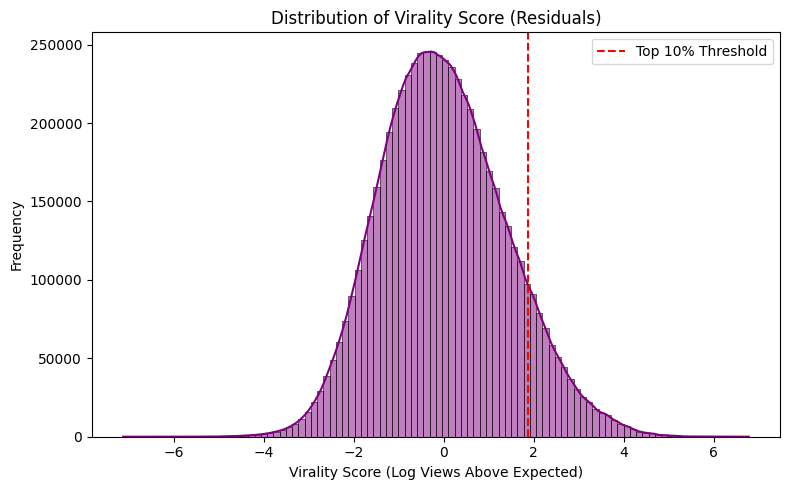

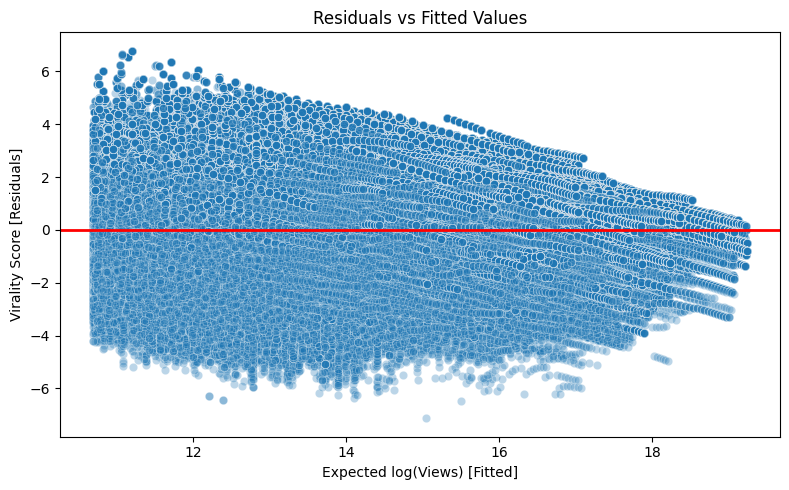

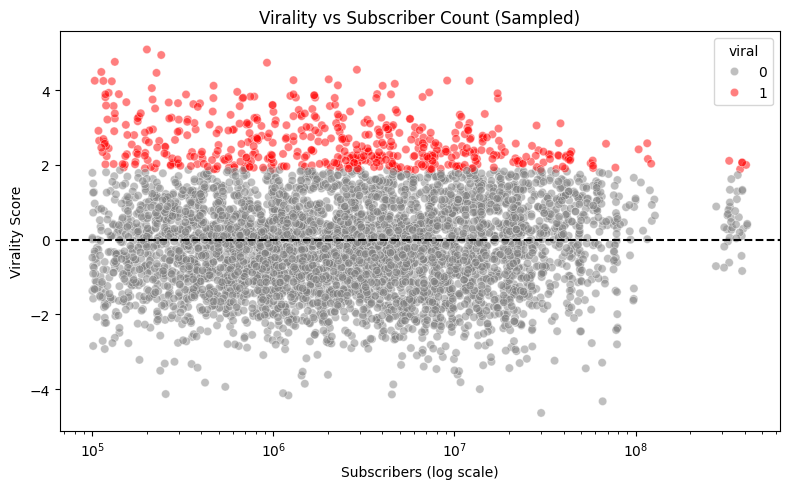

In [ ]:
# module 1: virality model via log-linear regression
# virality = deviation from expected views based on channel size and time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet(r"./data.parquet")

# parse and clean data
df['duration_sec'] = pd.to_timedelta(df['video_duration']).dt.total_seconds()
df['duration_min'] = df['duration_sec'] / 60

# convert numeric and datetime fields
df['view_count']       = pd.to_numeric(df['video_view_count'], errors='coerce')
df['like_count']       = pd.to_numeric(df['video_like_count'], errors='coerce')
df['comment_count']    = pd.to_numeric(df['video_comment_count'], errors='coerce')
df['subscriber_count'] = pd.to_numeric(df['channel_subscriber_count'], errors='coerce')

df['published_at']  = pd.to_datetime(df['video_published_at'], utc=True, errors='coerce')
df['trending_date'] = pd.to_datetime(df['video_trending__date'], utc=True, errors='coerce')

# calculate baseline engagement rates
df['like_rate']    = df['like_count'] / df['view_count']
df['comment_rate'] = df['comment_count'] / df['view_count']

# filter invalid, missing, or extreme outliers
df = df[df['video_category_id'] != 'Movies']
df_clean = df[df['duration_min'] <= 60].copy()

df_clean = df_clean.dropna(subset=[
    'view_count', 'subscriber_count',
    'published_at', 'trending_date'
])

df_clean['days_since_upload'] = (
    (df_clean['trending_date'] - df_clean['published_at'])
    .dt.days.clip(lower=1)
)

# log transformations for linear relationship modeling
df_clean['log_views'] = np.log1p(df_clean['view_count'])
df_clean['log_subs']  = np.log1p(df_clean['subscriber_count'])
df_clean['log_days']  = np.log1p(df_clean['days_since_upload'])


# calculate ordinary least squares regression using numpy
X_mat = np.column_stack([
    np.ones(len(df_clean)),      # intercept
    df_clean['log_subs'].values, # predictor 1
    df_clean['log_days'].values  # predictor 2
])

y_vec = df_clean['log_views'].values

# solve for coefficients
coefficients, sum_squared_residuals, rank, singular_values = np.linalg.lstsq(X_mat, y_vec, rcond=None)

intercept = coefficients[0]
coef_subs = coefficients[1]
coef_days = coefficients[2]

# calculate fitted values and overall model fit (r-squared)
fitted_values = X_mat @ coefficients
residuals = y_vec - fitted_values

ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_vec - np.mean(y_vec))**2)
r_squared = 1 - (ss_res / ss_tot)

print("\n--- custom regression summary ---")
print(f"R-squared: {r_squared:.4f}")
print(f"Intercept (β0): {intercept:.4f}")
print(f"Log_Subs Coef (β1): {coef_subs:.4f}")
print(f"Log_Days Coef (β2): {coef_days:.4f}")
print("Equation: log(Views) = β0 + β1*log(Subs) + β2*log(Days)")


# isolate virality score (residuals)
# positive = over-performed expectations, negative = under-performed
df_clean['virality_score'] = residuals
df_clean['fitted_log_views'] = fitted_values 

# define viral threshold as the top 10% of residuals
viral_threshold = df_clean['virality_score'].quantile(0.90)
df_clean['viral'] = (df_clean['virality_score'] >= viral_threshold).astype(int)

# generate summary statistics
numeric_cols = [
    'view_count', 'like_count', 'comment_count',
    'subscriber_count', 'duration_min',
    'like_rate', 'comment_rate',
    'virality_score'
]

summary = df_clean[numeric_cols].describe().T
summary['skew']   = df_clean[numeric_cols].skew()
summary['median'] = df_clean[numeric_cols].median()

print("\n--- summary statistics ---")
print(summary[['count', 'mean', 'median', 'std', 'min', 'max', 'skew']].round(2).to_string())

print("\n--- virality overview ---")
print(f"Viral Threshold (Top 10% Residual): {viral_threshold:.4f}")
print(df_clean['viral'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))


# generate visualizations

# plot virality distribution
plt.figure(figsize=(8,5))
sns.histplot(df_clean['virality_score'], bins=100, kde=True, color='purple')
plt.axvline(viral_threshold, color='red', linestyle='--', label='top 10% threshold')
plt.title("distribution of virality score (residuals)")
plt.xlabel("virality score (log views above expected)")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()

# plot residual diagnostics
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['fitted_log_views'], y=df_clean['virality_score'], alpha=0.3)
plt.axhline(0, color='red', linewidth=2)
plt.title("residuals vs fitted values")
plt.xlabel("expected log(views) [fitted]")
plt.ylabel("virality score [residuals]")
plt.tight_layout()
plt.show()

# plot virality vs subscribers
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='subscriber_count',
    y='virality_score',
    hue='viral',
    palette={0: 'gray', 1: 'red'},
    data=df_clean.sample(min(5000, len(df_clean))),
    alpha=0.5
)
plt.xscale('log')
plt.axhline(0, color='black', linestyle='--')
plt.title("virality vs subscriber count (sampled)")
plt.xlabel("subscribers (log scale)")
plt.ylabel("virality score")
plt.tight_layout()
plt.show()

--- logistic regression coefficients ---
     feature  coefficient
   like_rate    -0.234414
    log_subs    -0.286275
comment_rate    -0.650338
duration_min    -1.350730

--- classification report (threshold: 0.65) ---
               precision    recall  f1-score   support

not viral (0)       0.95      0.83      0.89   1110452
    viral (1)       0.29      0.62      0.40    122506

     accuracy                           0.81   1232958
    macro avg       0.62      0.73      0.64   1232958
 weighted avg       0.89      0.81      0.84   1232958



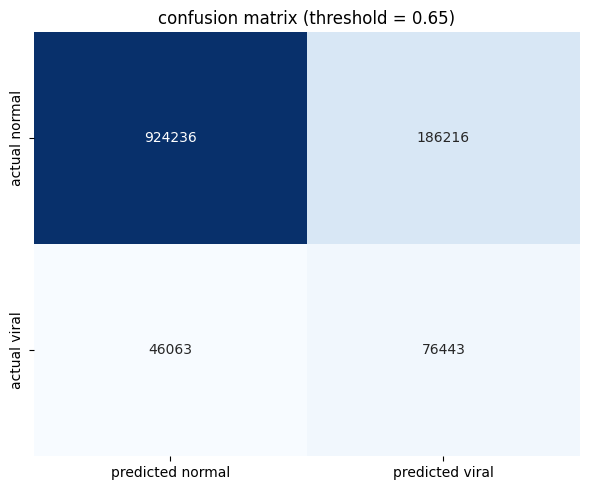

In [6]:
# Module 2: classify virality using logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# select features (using engagement metrics, not raw views)
features = ['duration_min', 'like_rate', 'comment_rate', 'log_subs']
model_df = df_clean.dropna(subset=features + ['viral']).copy()

X = model_df[features]
y = model_df['viral']

# train/test split (stratify maintains the 90/10 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# feature scaling (standardize scales for distance-based gradients)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train model (class_weight handles imbalanced data)
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# threshold tuning (0.65) to reduce false positives
y_probabilities = log_reg.predict_proba(X_test_scaled)[:, 1]
custom_threshold = 0.65
y_pred = (y_probabilities >= custom_threshold).astype(int)

# evaluate results
print("--- logistic regression coefficients ---")
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': log_reg.coef_[0]
}).sort_values(by='coefficient', ascending=False)
print(coef_df.to_string(index=False))

print(f"\n--- classification report (threshold: {custom_threshold}) ---")
print(classification_report(y_test, y_pred, target_names=['not viral (0)', 'viral (1)']))

# visualize confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['predicted normal', 'predicted viral'],
            yticklabels=['actual normal', 'actual viral'])
plt.title(f"confusion matrix (threshold = {custom_threshold})")
plt.tight_layout()
plt.show()

For YouTube's algorithm, classifying a non-viral video as viral (False Positive) is significantly worse. If the algorithm mistakenly thinks a mediocre video is a "viral hit" and pushes it to millions of homepages, viewers will click it, get bored, and leave the app. YouTube loses watch time and ad revenue.

On the other hand, if the algorithm misses a truly viral video (False Negative), it’s not a huge loss. There are always thousands of other good videos to recommend. The algorithm’s primary goal is to protect the user's feed from garbage, which means Precision (being right when you guess "viral") is more important than Recall (catching every single viral video).

### Interpretation 


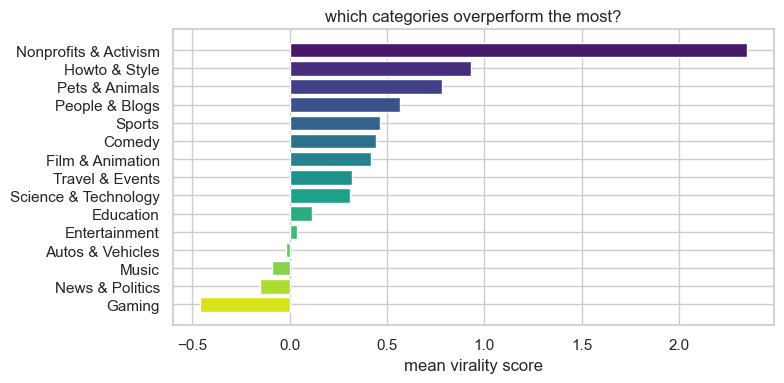

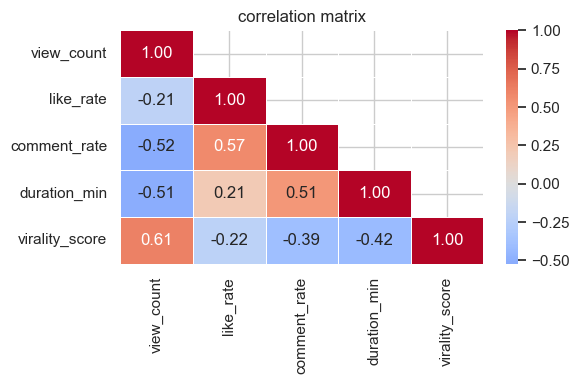

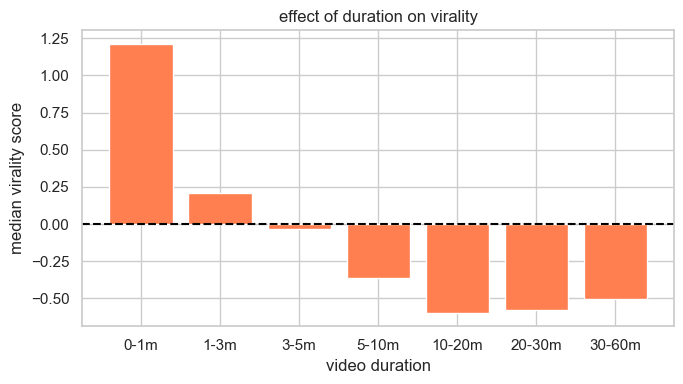

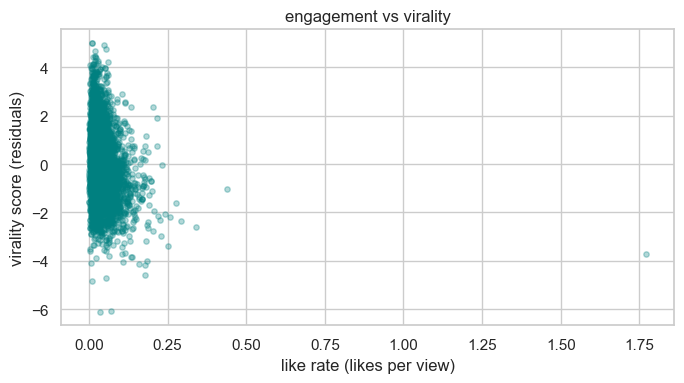

In [7]:
# module 1.5: exploratory data analysis (eda)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# category statistics
cat_stats = (
    df_clean.groupby("video_category_id")
    .agg(
        video_count=("view_count", "count"),
        median_views=("view_count", "median"),
        median_duration=("duration_min", "median"),
        viral_rate=("viral", "mean"),
        mean_virality=("virality_score", "mean"),
    )
    .sort_values("mean_virality", ascending=False)
    .round(3)
)

sns.set_theme(style="whitegrid")

# fig 1: mean virality by category
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cat_stats.index, cat_stats["mean_virality"], color=sns.color_palette("viridis", len(cat_stats)))
ax.set_xlabel("mean virality score")
ax.set_title("which categories overperform the most?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# fig 2: correlation matrix
fig, ax = plt.subplots(figsize=(6, 4))
corr_cols = ["view_count", "like_rate", "comment_rate", "duration_min", "virality_score"]
corr = df_clean[corr_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4, ax=ax)
ax.set_title("correlation matrix")
plt.tight_layout()
plt.show()

# fig 3: duration vs virality (supports our logistic regression findings)
df_clean["duration_bin"] = pd.cut(
    df_clean["duration_min"],
    bins=[0, 1, 3, 5, 10, 20, 30, 60],
    labels=["0-1m", "1-3m", "3-5m", "5-10m", "10-20m", "20-30m", "30-60m"],
)

fig, ax = plt.subplots(figsize=(7, 4))
dur_virality = df_clean.groupby("duration_bin", observed=True)["virality_score"].median()
ax.bar(dur_virality.index.astype(str), dur_virality.values, color='coral')
ax.set_xlabel("video duration")
ax.set_ylabel("median virality score")
ax.axhline(0, color='black', linestyle='--')
ax.set_title("effect of duration on virality")
plt.tight_layout()
plt.show()

# fig 4: engagement vs virality (supports our logistic regression findings)
fig, ax = plt.subplots(figsize=(7, 4))
sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

ax.scatter(sample["like_rate"], sample["virality_score"], alpha=0.3, s=15, color='teal')
ax.set_xlabel("like rate (likes per view)")
ax.set_ylabel("virality score (residuals)")
ax.set_title("engagement vs virality")
plt.tight_layout()
plt.show()

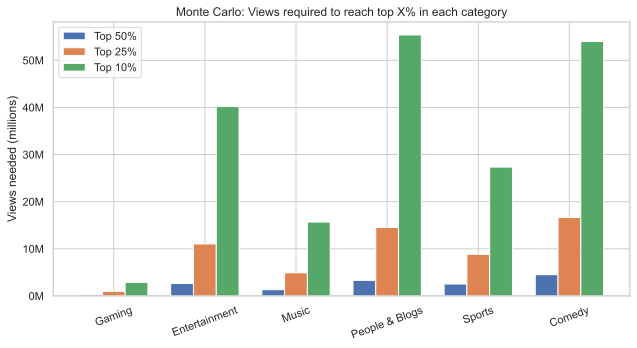

In [3]:
#Monte Carlo Method : simulating view distributions per category
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Top categories (by volume)
top_cats = (
    df_clean["video_category_id"]
    .value_counts()
    .head(6)
    .index
)

target_percentiles = [50, 75, 90]
sim_thresholds = {}

for cat in top_cats:
    views = df_clean.loc[
        df_clean["video_category_id"] == cat, "view_count"
    ].dropna().values
    
    lv = np.log(views[views > 0])
    
    sim = np.random.lognormal(
        mean=lv.mean(),
        sigma=lv.std(),
        size=50_000
    )
    
    sim_thresholds[cat] = {
        f"Top {100-p}%": np.percentile(sim, p) / 1e6
        for p in target_percentiles
    }

thresh_df = pd.DataFrame(sim_thresholds).T

# Plot
x = np.arange(len(top_cats))
width = 0.25

fig, ax = plt.subplots(figsize=(9,5))
for i, col in enumerate(thresh_df.columns):
    ax.bar(x + i*width, thresh_df[col], width, label=col)

ax.set_xticks(x + width)
ax.set_xticklabels(thresh_df.index, rotation=20)
ax.set_ylabel("Views needed (millions)")
ax.set_title("Monte Carlo: Views required to reach top X% in each category")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.legend()
plt.tight_layout()
plt.show()

### QQ Plot